# Day 22 — Portfolio Rebalancing

Compare two historical strategies:
1. Equal-weight buy-and-hold
2. Monthly rebalancing to 20% per stock

Starting capital: $100,000
Transaction cost: 0.10% of traded value

In [1]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect("hedge_fund.db")

prices = pd.read_sql_query("""
SELECT date, ticker, close_price
FROM daily_prices
WHERE ticker IN ('AAPL', 'BLK', 'GS', 'JPM', 'MSFT')
ORDER BY date, ticker
""", conn)

prices["date"] = pd.to_datetime(prices["date"])

price_matrix = prices.pivot(
    index="date",
    columns="ticker",
    values="close_price"
).sort_index()

assert not price_matrix.isna().any().any()
assert (price_matrix > 0).all().all()

display(price_matrix.head())

ticker,AAPL,BLK,GS,JPM,MSFT
date,,,,,
2025-09-23,253.493591,1108.070068,790.766968,306.869354,505.074463
2025-09-24,251.381409,1104.378906,777.144836,307.536621,505.986908
2025-09-25,255.924637,1123.284790,779.429932,307.566071,502.892334
2025-09-26,254.519806,1132.253052,787.030518,310.127045,507.286194
2025-09-29,253.493591,1150.963501,788.609436,309.764008,510.400513


In [2]:


initial_capital = 100_000
n_assets = len(price_matrix.columns)
target_weights = np.repeat(1 / n_assets, n_assets)

# Fractional shares; no initial transaction costs
initial_shares = (
    initial_capital * target_weights
    / price_matrix.iloc[0].to_numpy()
)

buy_hold_equity = (
    price_matrix.to_numpy() * initial_shares
).sum(axis=1)

buy_hold = pd.Series(
    buy_hold_equity,
    index=price_matrix.index,
    name="Buy and Hold"
)

display(buy_hold.head())

date
2025-09-23    100000.000000
2025-09-24     99501.821069
2025-09-25    100138.684517
2025-09-26    100722.850271
2025-09-29    101119.191263
Name: Buy and Hold, dtype: float64

In [3]:

transaction_cost_rate = 0.001

# Last available trading day in each calendar month
month_end_dates = set(
    price_matrix.groupby(
        price_matrix.index.to_period("M")
    ).tail(1).index
)

# Start with the same holdings as buy-and-hold
shares = initial_shares.copy()
cash = 0.0

records = []

for date, row in price_matrix.iterrows():
    current_prices = row.to_numpy()
    holdings = shares * current_prices
    equity_before = holdings.sum() + cash

    traded_value = 0.0
    fees = 0.0

    if date in month_end_dates and date != price_matrix.index[-1]:
        # Solve for post-fee equity so fees are funded
        # from the portfolio itself.
        post_fee_equity = equity_before

        for _ in range(100):
            target_values = (
                post_fee_equity * target_weights
            )

            traded_value = np.abs(
                target_values - holdings
            ).sum()

            updated_equity = (
                equity_before
                - transaction_cost_rate * traded_value
            )

            if abs(updated_equity - post_fee_equity) < 1e-8:
                post_fee_equity = updated_equity
                break

            post_fee_equity = updated_equity

        fees = equity_before - post_fee_equity
        shares = target_values / current_prices
        cash = post_fee_equity - target_values.sum()

    records.append({
        "date": date,
        "equity": equity_before - fees,
        "traded_value": traded_value,
        "fees": fees
    })

rebalanced = pd.DataFrame(records).set_index("date")

display(rebalanced.head())
print("Total transaction costs:",
      round(rebalanced["fees"].sum(), 2))

,equity,traded_value,fees
date,,,
2025-09-23,100000.000000,0.0,0.0
2025-09-24,99501.821069,0.0,0.0
2025-09-25,100138.684517,0.0,0.0
2025-09-26,100722.850271,0.0,0.0
2025-09-29,101119.191263,0.0,0.0


Total transaction costs: 48.52


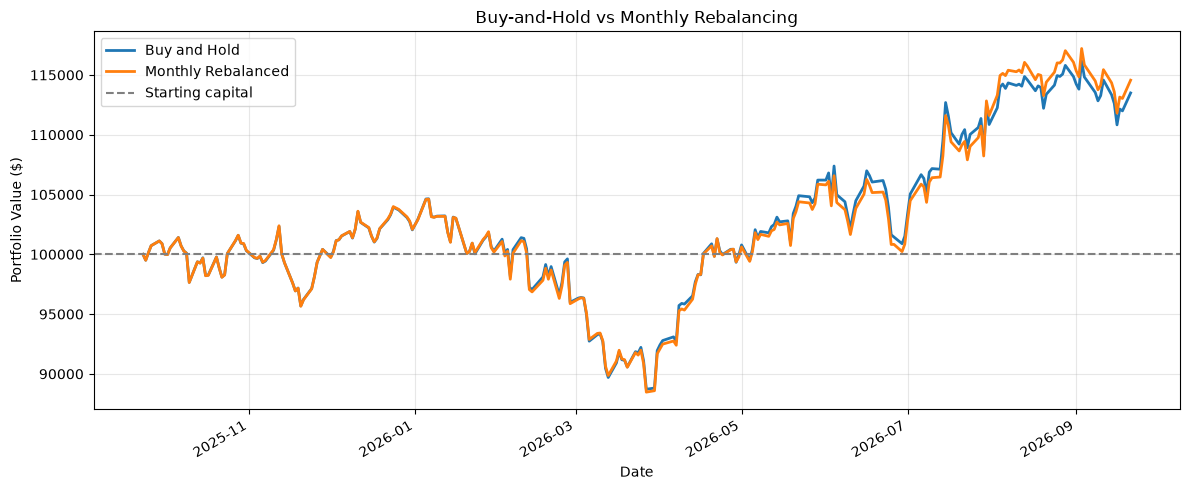

In [4]:

comparison = pd.DataFrame({
    "Buy and Hold": buy_hold,
    "Monthly Rebalanced": rebalanced["equity"]
})

ax = comparison.plot(figsize=(12, 5), linewidth=2)

ax.axhline(
    initial_capital,
    color="gray",
    linestyle="--",
    label="Starting capital"
)

ax.set_title("Buy-and-Hold vs Monthly Rebalancing")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [5]:

def calculate_metrics(equity):
    daily_returns = equity.pct_change().dropna()

    total_return = equity.iloc[-1] / equity.iloc[0] - 1

    annualized_return = (
        (equity.iloc[-1] / equity.iloc[0])
        ** (252 / len(daily_returns)) - 1
    )

    annualized_volatility = (
        daily_returns.std() * np.sqrt(252)
    )

    sharpe_ratio = (
        daily_returns.mean() * 252
        / annualized_volatility
        if annualized_volatility > 0
        else np.nan
    )

    drawdown = equity / equity.cummax() - 1

    return {
        "Total Return (%)": total_return * 100,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Volatility (%)":
            annualized_volatility * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown (%)": drawdown.min() * 100
    }

results = pd.DataFrame({
    "Buy and Hold":
        calculate_metrics(comparison["Buy and Hold"]),
    "Monthly Rebalanced":
        calculate_metrics(comparison["Monthly Rebalanced"])
})

display(results.round(2))

,Buy and Hold,Monthly Rebalanced
Total Return (%),13.49,14.56
Annualized Return (%),13.67,14.75
Annualized Volatility (%),18.26,18.15
Sharpe Ratio,0.79,0.85
Maximum Drawdown (%),-15.22,-15.43


In [6]:

rebalanced["turnover_pct"] = (
    rebalanced["traded_value"]
    / rebalanced["equity"] * 100
)

trading_summary = pd.DataFrame({
    "Metric": [
        "Rebalancing events",
        "Total traded value",
        "Total transaction costs",
        "Cumulative turnover (%)"
    ],
    "Value": [
        int((rebalanced["traded_value"] > 0).sum()),
        round(rebalanced["traded_value"].sum(), 2),
        round(rebalanced["fees"].sum(), 2),
        round(rebalanced["turnover_pct"].sum(), 2)
    ]
})

display(trading_summary)

,Metric,Value
0,Rebalancing events,12.00
1,Total traded value,48517.55
2,Total transaction costs,48.52
3,Cumulative turnover (%),47.15


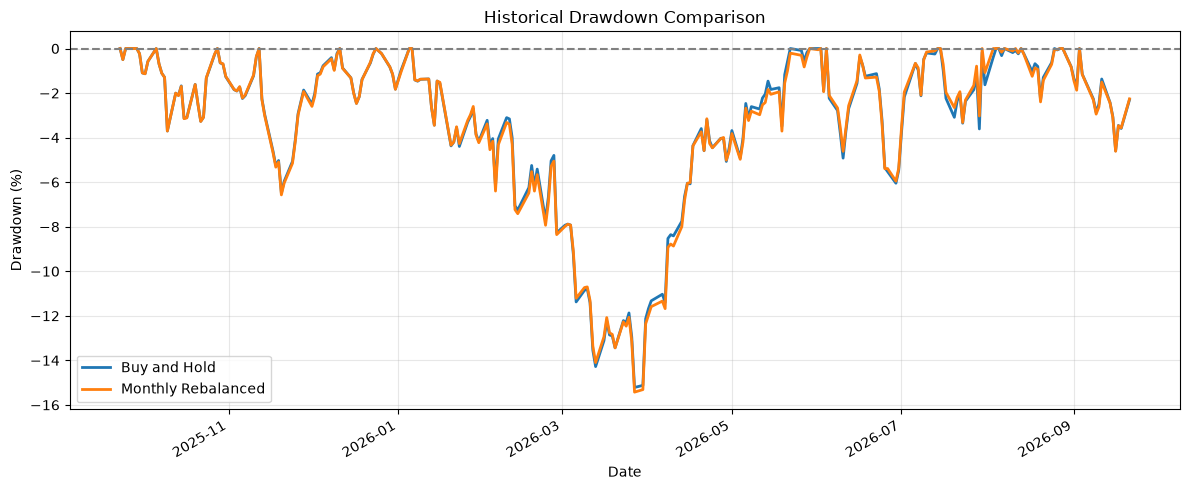

In [7]:

drawdowns = comparison.div(
    comparison.cummax()
).sub(1).mul(100)

ax = drawdowns.plot(figsize=(12, 5), linewidth=2)

ax.axhline(0, color="gray", linestyle="--")
ax.set_title("Historical Drawdown Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()